# Qwen3.5-0.8B serving smoke experiment

This notebook is the analysis and launch surface for `qwen35-0.8b-smoke`. It loads the real YAML profile, expands the same matrix as the CLI, reads the harness's canonical `manifest.json` and `summary.json` artifacts, and keeps quality evidence separate from performance.

**Safe default:** Run All is offline and read-only. It does not connect over SSH, provision a Pod, invoke the runner, or make a paid call. The launch cell runs only after `RUN_EXPERIMENT = True` is set deliberately.

In [1]:
from pathlib import Path
import os
import shlex
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from IPython.display import Markdown, display

def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'experiment_profiles' / 'qwen35-0.8b-smoke.yaml').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from within the llm-serving checkout.')

PROJECT_ROOT = find_project_root(Path.cwd())
PROFILE_PATH = PROJECT_ROOT / 'experiment_profiles' / 'qwen35-0.8b-smoke.yaml'
OUTPUT_ROOT = Path(os.environ.get('LLM_SERVING_OUTPUT_ROOT', PROJECT_ROOT / 'output')).expanduser().resolve()
FIXTURE_ROOT = PROJECT_ROOT / 'notebooks' / 'fixtures'

from llm_serving.analysis import (
    comparable_quality_groups, discover_runs, history_rows, performance_rows,
    plot_baseline_deltas, plot_performance, plot_quality, quality_rows, write_run_notes,
)
from llm_serving.matrix import expand_matrix
from llm_serving.schemas import ExperimentProfile

print(f'Project: {PROJECT_ROOT}')
print(f'Artifact root: {OUTPUT_ROOT}')

Project: /home/kevin/Workspace/toyai-worktrees/experiment-notebook/llm-serving
Artifact root: /home/kevin/Workspace/toyai-worktrees/experiment-notebook/llm-serving/output


## Question and hypothesis

The smoke profile asks whether CUDA graph execution improves Qwen3.5-0.8B serving performance for short-interactive, long-prefill, near-limit-prefill, and decode-heavy traffic while chunked prefill remains enabled for the model's aligned Mamba cache mode.

The working hypothesis is that CUDA graphs increase output throughput and reduce inter-token latency most clearly on decode-heavy traffic. LongBench v2, GSM8K, and SuperGLUE are separate smoke-quality checks; their 20-example results are not full benchmark scores and must not be used to explain a performance delta. The 16K serving cap also makes this LongBench v2 result a constrained smoke slice rather than a leaderboard result.

In [2]:
profile_raw = yaml.safe_load(PROFILE_PATH.read_text(encoding='utf-8'))
profile = ExperimentProfile.model_validate(profile_raw)
display(Markdown(f'**Loaded profile:** `{PROFILE_PATH}`  \n**Model:** `{profile.model.id}` at revision `{profile.model.revision}`'))
pd.json_normalize(profile.model_dump(), sep='.').T.rename(columns={0: 'resolved value'})

**Loaded profile:** `/home/kevin/Workspace/toyai-worktrees/experiment-notebook/llm-serving/experiment_profiles/qwen35-0.8b-smoke.yaml`  
**Model:** `Qwen/Qwen3.5-0.8B` at revision `main`

,resolved value
schema_version,1
name,qwen35-0.8b-smoke
model.id,Qwen/Qwen3.5-0.8B
model.revision,main
model.variant,BF16
model.dtype,auto
model.quantization,None
model.model_card.url,https://huggingface.co/Qwen/Qwen3.5-0.8B
model.model_card.config_url,https://huggingface.co/Qwen/Qwen3.5-0.8B/blob/...
model.model_card.max_position_embeddings,262144


## Resolved experiment matrix

This uses the harness's matrix expansion rather than reimplementing it in the notebook. The first row is the within-run baseline used by the saved reports.

In [3]:
matrix = expand_matrix(profile)
matrix_df = pd.DataFrame([
    {
        'case_id': case.case_id, 'baseline': case.is_baseline,
        'cuda_graphs': case.cuda_graphs, 'chunked_prefill': case.chunked_prefill,
        'repetition': case.repetition, 'vllm_args': shlex.join(case.vllm_args),
    }
    for case in matrix
])
matrix_df

,case_id,baseline,cuda_graphs,chunked_prefill,repetition,vllm_args
0,case-00-cg1-cp1-rep0,True,True,True,0,--model Qwen/Qwen3.5-0.8B --revision main --te...
1,case-01-cg0-cp1-rep0,False,False,True,0,--model Qwen/Qwen3.5-0.8B --revision main --te...


## Explicit launch controls

Edit the host alias and inventory path for an existing SSH host or a prepared temporary inventory. The existing harness command runs only when the switch in the next cell is changed to `True`.

Set the hypothesis before launch so the new run receives an `experiment-notes.json` sidecar. The notebook creates that sidecar only for the newly created run and refuses to replace an existing notes file.

In [4]:
HOST = os.environ.get('LLM_SERVING_HOST', 'replace-with-host-alias')
HOST_INVENTORY = Path(os.environ.get('LLM_SERVING_HOST_INVENTORY', PROJECT_ROOT / 'hosts.local.yaml')).expanduser()
HYPOTHESIS = 'CUDA graphs improve decode-heavy throughput and ITL on this host.'
INITIAL_OBSERVATIONS = ''

plan_command = [sys.executable, '-m', 'llm_serving.cli', 'plan', str(PROFILE_PATH), '--host', HOST, '--inventory', str(HOST_INVENTORY)]
run_command = [sys.executable, '-m', 'llm_serving.cli', 'run', str(PROFILE_PATH), '--host', HOST, '--inventory', str(HOST_INVENTORY), '--output-dir', str(OUTPUT_ROOT)]
display(Markdown('**Offline plan preview**\n```shell\n' + shlex.join(plan_command) + '\n```'))
display(Markdown('**Existing-harness run preview**\n```shell\n' + shlex.join(run_command) + '\n```'))

**Offline plan preview**
```shell
/home/kevin/Workspace/toyai-worktrees/experiment-notebook/llm-serving/.venv/bin/python3 -m llm_serving.cli plan /home/kevin/Workspace/toyai-worktrees/experiment-notebook/llm-serving/experiment_profiles/qwen35-0.8b-smoke.yaml --host runpod-qwen08 --inventory /home/kevin/Workspace/toyai-worktrees/experiment-notebook/llm-serving/.flash/hosts/t7k4fs7sttu4t9.yaml
```

**Existing-harness run preview**
```shell
/home/kevin/Workspace/toyai-worktrees/experiment-notebook/llm-serving/.venv/bin/python3 -m llm_serving.cli run /home/kevin/Workspace/toyai-worktrees/experiment-notebook/llm-serving/experiment_profiles/qwen35-0.8b-smoke.yaml --host runpod-qwen08 --inventory /home/kevin/Workspace/toyai-worktrees/experiment-notebook/llm-serving/.flash/hosts/t7k4fs7sttu4t9.yaml --output-dir /home/kevin/Workspace/toyai-worktrees/experiment-notebook/llm-serving/output
```

In [5]:
RUN_EXPERIMENT = os.environ.get('LLM_SERVING_RUN_EXPERIMENT', '').lower() in {'1', 'true', 'yes'}  # Deliberate opt-in: may use SSH/GPU resources and incur cost.

if not RUN_EXPERIMENT:
    print('Analysis-only mode: no validation, SSH, provisioning, or experiment run was started.')
else:
    if HOST == 'replace-with-host-alias':
        raise ValueError('Set LLM_SERVING_HOST or edit HOST before launching.')
    if not HOST_INVENTORY.is_file():
        raise FileNotFoundError(f'Host inventory not found: {HOST_INVENTORY}')
    run_parent = OUTPUT_ROOT / profile.name
    before = {path for path in run_parent.iterdir() if path.is_dir() and (path / 'summary.json').is_file()} if run_parent.is_dir() else set()
    completed = subprocess.run(run_command, cwd=PROJECT_ROOT, check=False)
    after = {path for path in run_parent.iterdir() if path.is_dir() and (path / 'summary.json').is_file()}
    created = sorted(after - before)
    if len(created) == 1:
        notes_path = write_run_notes(created[0], hypothesis=HYPOTHESIS, observations=INITIAL_OBSERVATIONS)
        print(f'Run notes created: {notes_path}')
    else:
        raise RuntimeError(f'Expected one new run directory, found {created}')
    print(f'Harness exit code: {completed.returncode}. Failed runs remain available for analysis.')

[2026-09-28 17:50:46,819] INFO: Step 1/5: Validating profile and host locally...
[2026-09-28 17:50:46,819] INFO: Step 2/5: Synchronizing project to remote host...


[2026-09-28 17:50:49,005] INFO: Step 3/5: Running remote preflight checks...


[2026-09-28 17:50:59,155] INFO: Step 4/5: Ensuring remote vLLM runtime is available...


[2026-09-28 17:51:00,074] INFO: Step 5/5: Executing parameter sweep matrix...
[2026-09-28 17:51:00,074] INFO: Executing case-00-cg1-cp1-rep0 (attempt 1/2)...


[2026-09-28 17:56:38,277] INFO: Running quality evaluation on the baseline server...


[2026-09-28 18:41:02,755] INFO: Executing case-01-cg0-cp1-rep0 (attempt 1/2)...


[2026-09-28 18:50:32,884] INFO: Synchronizing remote artifacts back to local output...



✓ Experiment finished successfully!
Artifacts saved to: 
/home/kevin/Workspace/toyai-worktrees/experiment-notebook/llm-serving/output/qwe
n35-0.8b-smoke/20260929_005046
Report: 
/home/kevin/Workspace/toyai-worktrees/experiment-notebook/llm-serving/output/qwe
n35-0.8b-smoke/20260929_005046/report.md
Run notes created: /home/kevin/Workspace/toyai-worktrees/experiment-notebook/llm-serving/output/qwen35-0.8b-smoke/20260929_005046/experiment-notes.json
Harness exit code: 0. Failed runs remain available for analysis.


## Saved run history

The reader includes failed and partial runs. Missing files and metrics remain visible warnings or blank values; they are never replaced with zero. If the selected output root has no measured performance rows, the notebook uses bundled **synthetic fixtures** to exercise the tables and charts.

In [6]:
measured_runs = discover_runs(OUTPUT_ROOT, profile_name=profile.name, source='measured')
fixture_runs = discover_runs(FIXTURE_ROOT, profile_name=profile.name, source='synthetic fixture')
history = measured_runs if measured_runs else fixture_runs
if measured_runs:
    display(Markdown(f'**Measured artifact history:** {len(measured_runs)} run(s) found.'))
else:
    display(Markdown('> **Synthetic fixture history shown.** No measured runs were found under the selected output root. Fixture values demonstrate the analysis only; they are not benchmark results.'))
pd.DataFrame(history_rows(history))

**Measured artifact history:** 6 run(s) found.

,run_id,source,status,complete,started_at,duration_seconds,gpu_model,hypothesis,warnings,run_dir
0,20260929_005046,measured,SUCCESS,True,2026-09-29T00:50:46.817854+00:00,3586.066682,NVIDIA GeForce RTX 4090,CUDA graphs improve decode-heavy throughput an...,,/home/kevin/Workspace/toyai-worktrees/experime...
1,20260928_235811,measured,ABORTED,False,2026-09-28T23:58:11.173728+00:00,294.953376,NVIDIA GeForce RTX 4090,CUDA graphs improve decode-heavy throughput an...,1 case(s) are incomplete or failed,/home/kevin/Workspace/toyai-worktrees/experime...
2,20260928_233905,measured,FAILED,False,2026-09-28T23:39:05.973486+00:00,1105.670465,NaN,CUDA graphs improve decode-heavy throughput an...,,/home/kevin/Workspace/toyai-worktrees/experime...
3,20260928_233543,measured,FAILED,False,2026-09-28T23:35:43.166800+00:00,15.870874,NaN,NaN,,/home/kevin/Workspace/toyai-worktrees/experime...
4,synthetic-run-b,synthetic fixture,PARTIAL,False,2026-01-02T00:00:00+00:00,180.000000,Synthetic GPU,Synthetic example: repeat the smoke comparison...,1 case(s) are incomplete or failed,/home/kevin/Workspace/toyai-worktrees/experime...
5,synthetic-run-a,synthetic fixture,SUCCESS,True,2026-01-01T00:00:00+00:00,300.000000,Synthetic GPU,Synthetic example: CUDA graphs improve decode ...,,/home/kevin/Workspace/toyai-worktrees/experime...


## Performance results

These panels show throughput, TTFT p50/p95, ITL p50/p95, and end-to-end latency only where the artifacts record them. Blue bars are baseline cases and orange bars are alternatives. Variability is not drawn because the current profile has one repetition per case; increase repetitions before interpreting run-to-run spread.

In [7]:
measured_performance = performance_rows(measured_runs)
requested_ids = {value.strip() for value in os.environ.get('LLM_SERVING_RUN_IDS', '').split(',') if value.strip()}
if measured_performance:
    if requested_ids:
        analysis_runs = [run for run in measured_runs if run['run_id'] in requested_ids]
        if not performance_rows(analysis_runs):
            raise ValueError(f'LLM_SERVING_RUN_IDS selected no runs with performance rows: {sorted(requested_ids)}')
    else:
        analysis_runs = [next((run for run in measured_runs if run['complete'] and performance_rows([run])), next(run for run in measured_runs if performance_rows([run])))]
    display(Markdown('**Data source: measured harness artifacts.** Charts show the latest complete run by default; set `LLM_SERVING_RUN_IDS` to a comma-separated list for an explicit comparison.'))
else:
    analysis_runs = fixture_runs
    display(Markdown('> **Data source: synthetic fixtures.** The following values are illustrative and must not be reported as measurements.'))
perf = performance_rows(analysis_runs)
perf_df = pd.DataFrame(perf)
columns = ['run_id', 'source', 'case_id', 'case_status', 'config', 'workload', 'output_throughput_tok_per_s', 'ttft_p50_ms', 'ttft_p95_ms', 'itl_p50_ms', 'itl_p95_ms', 'e2e_p50_ms']
perf_df.reindex(columns=columns)

**Data source: measured harness artifacts.** Charts show the latest complete run by default; set `LLM_SERVING_RUN_IDS` to a comma-separated list for an explicit comparison.

,run_id,source,case_id,case_status,config,workload,output_throughput_tok_per_s,ttft_p50_ms,ttft_p95_ms,itl_p50_ms,itl_p95_ms,e2e_p50_ms
0,20260929_005046,measured,case-00-cg1-cp1-rep0,SUCCESS,CG on / CP on,Short interactive,1010.590628,55.430213,96.638517,2.876137,3.870266,None
1,20260929_005046,measured,case-00-cg1-cp1-rep0,SUCCESS,CG on / CP on,Long prefill,126.508787,309.544494,481.166799,2.635106,3.515639,None
2,20260929_005046,measured,case-00-cg1-cp1-rep0,SUCCESS,CG on / CP on,Near-limit prefill,120.700410,333.622455,364.659775,2.575730,3.185003,None
3,20260929_005046,measured,case-00-cg1-cp1-rep0,SUCCESS,CG on / CP on,Decode heavy,1860.182889,52.231570,82.727770,2.996912,3.474269,None
4,20260929_005046,measured,case-01-cg0-cp1-rep0,SUCCESS,CG off / CP on,Short interactive,847.158308,106.928289,139.877944,28.935482,48.739281,None
5,20260929_005046,measured,case-01-cg0-cp1-rep0,SUCCESS,CG off / CP on,Long prefill,119.315465,397.571001,586.594474,27.211609,48.370475,None
6,20260929_005046,measured,case-01-cg0-cp1-rep0,SUCCESS,CG off / CP on,Near-limit prefill,65.721911,417.236530,444.491420,26.535163,29.119305,None
7,20260929_005046,measured,case-01-cg0-cp1-rep0,SUCCESS,CG off / CP on,Decode heavy,528.255863,104.518490,132.676846,27.448392,30.970225,None


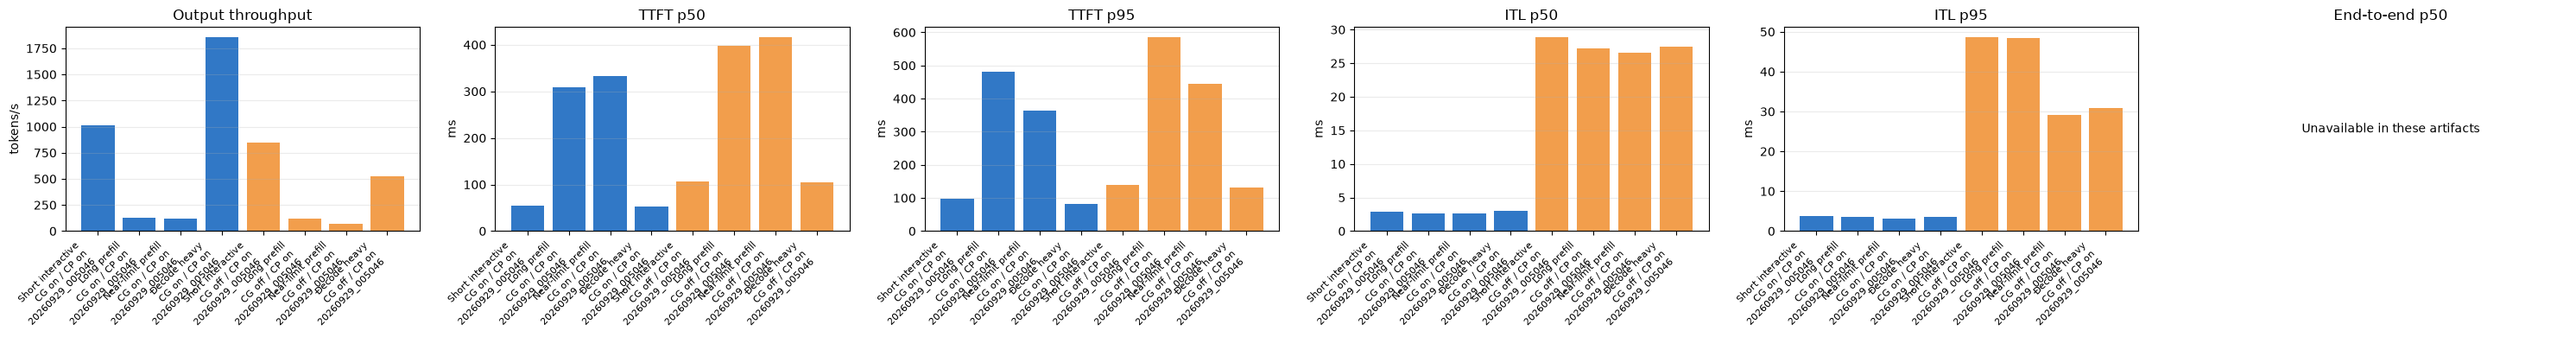

In [8]:
plot_performance(perf);


## Within-run baseline deltas

Deltas come directly from each canonical summary. Throughput gains are favorable; latency reductions are favorable. Cross-run deltas are not synthesized when hardware, runtime, or workload identity may differ.

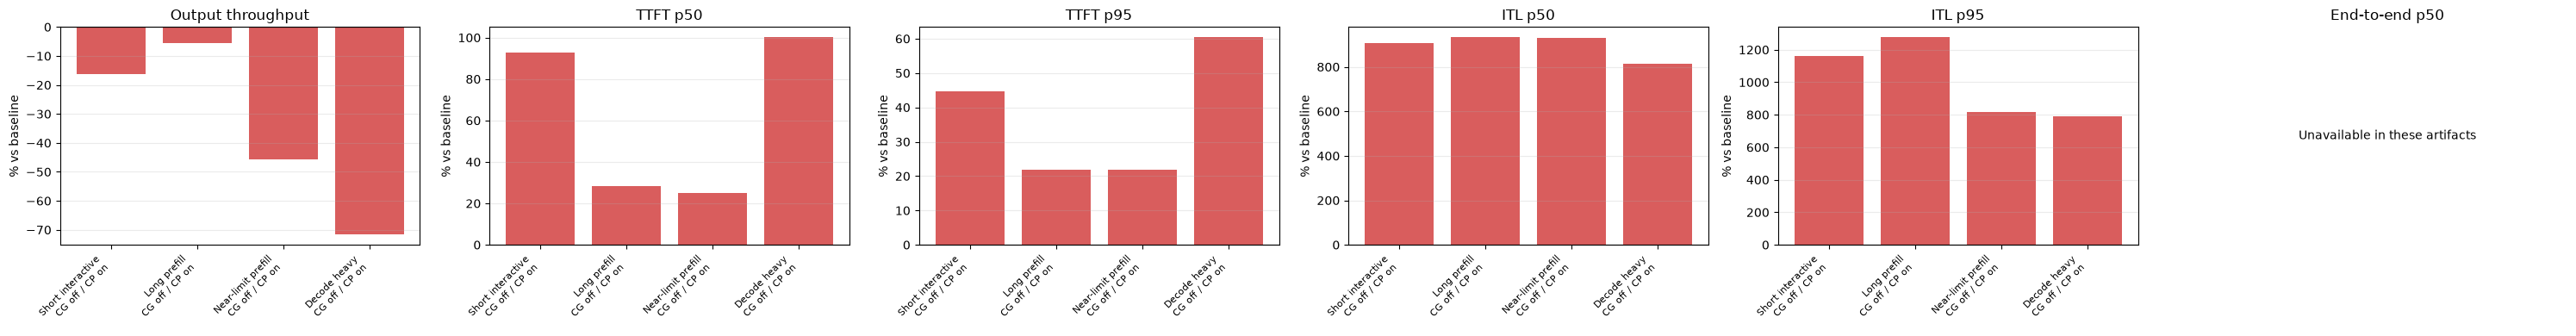

In [9]:
plot_baseline_deltas(perf);


## Quality evidence (separate from performance)

Quality rows are grouped only when their recorded task settings and named metric match. That check cannot establish compatibility for metadata the current artifacts do not record, such as evaluator version or prompt-template revision. LongBench v2, GSM8K, and SuperGLUE each use a 20-example smoke subset here; they are not leaderboard estimates. The profile's 16K serving cap further constrains LongBench v2.

**Data source: measured quality artifacts.**

,run_id,source,task_name,metric,score,stderr,evaluation_signature
0,20260929_005046,measured,longbench2_agent_history,"acc,none",0.150000,NaN,NaN
1,20260929_005046,measured,longbench2_dialogue_history,"acc,none",0.105263,NaN,NaN
2,20260929_005046,measured,longbench2_many_shot,"acc,none",0.300000,NaN,NaN
3,20260929_005046,measured,longbench2_translate,"acc,none",0.250000,NaN,NaN
4,20260929_005046,measured,longbench2_user_guide,"acc,none",0.250000,NaN,NaN
5,20260929_005046,measured,longbench2_academic_multi,"acc,none",0.150000,NaN,NaN
6,20260929_005046,measured,longbench2_fin_multi,"acc,none",0.333333,NaN,NaN
7,20260929_005046,measured,longbench2_govt_multi,"acc,none",0.200000,NaN,NaN
8,20260929_005046,measured,longbench2_legal_multi,"acc,none",0.285714,NaN,NaN
9,20260929_005046,measured,longbench2_news_multi,"acc,none",0.350000,NaN,NaN


Groups sharing recorded task settings and metric: 4


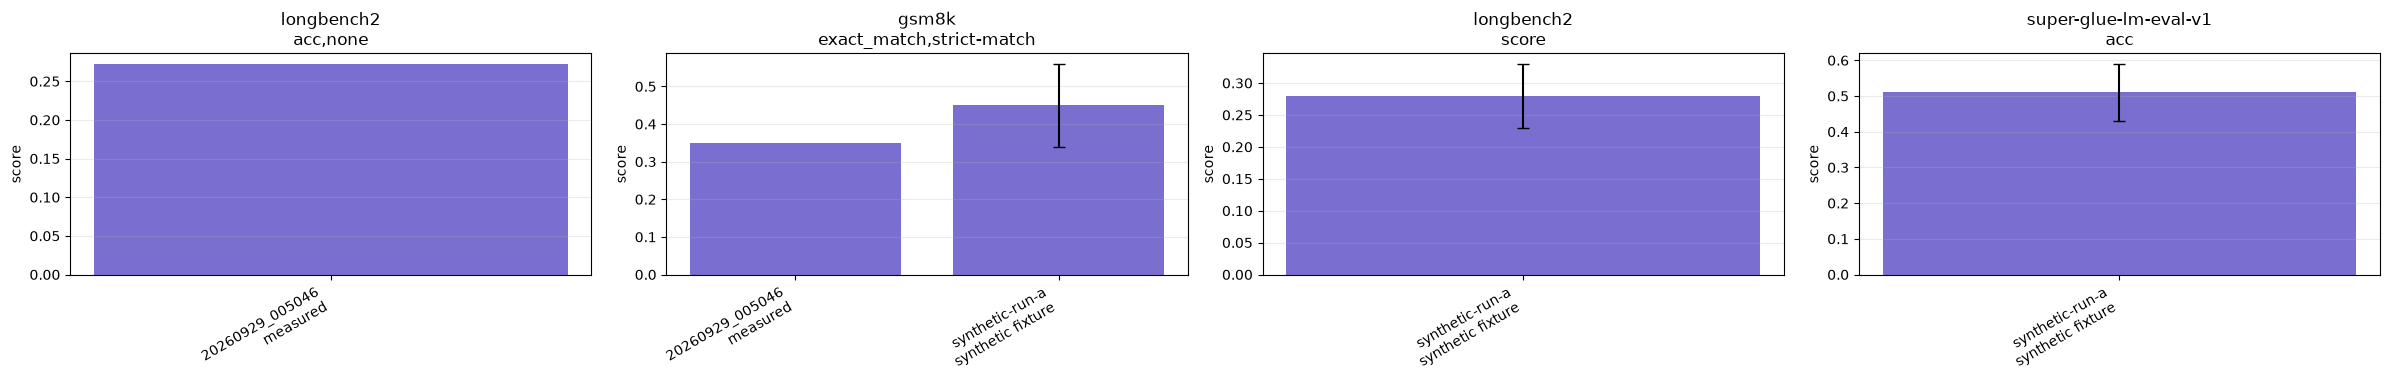

In [10]:
measured_quality = quality_rows(measured_runs)
if measured_quality:
    quality = measured_quality
    display(Markdown('**Data source: measured quality artifacts.**'))
else:
    quality = quality_rows(fixture_runs)
    display(Markdown('> **Data source: synthetic quality fixture.** No measured quality scores were found; this row demonstrates the schema only.'))
quality_df = pd.DataFrame(quality)
display(quality_df)
groups = comparable_quality_groups(quality)
print(f'Groups sharing recorded task settings and metric: {len(groups)}')
plot_quality(quality);

## Observations and next decision

After a real run, record what happened in that run's `experiment-notes.json` sidecar and rerun the analysis cells. Check completion and warning columns before comparing values. Treat missing E2E or quality values as unavailable. With one repetition, use the result to choose a focused repeat rather than claim stable variability.

Suggested decision: if the measured decode-heavy delta agrees with the hypothesis, repeat both cases at least three times on the same host/runtime. If a case failed, inspect its saved server log and keep the partial run in history.